<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/%5C4_PINN%5C1c_PINN_UnknownFuncs_Batching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PROBLEM SETTING (EPIDEMIC EXAMPLE- S,I,R model)

$$[y_1, y_2, y_3]=[S,I,R]$$
  $$\frac{dS}{dt} = (-\beta  S  I)$$
  $$ \frac{dI}{dt} = (\beta  S  I - \gamma  I)$$
  $$ \frac{dR}{dt} = (\gamma  I)$$

  We assume **we do not know**
  - $\beta$
  - functional form of $\frac{dR}{dt}$
  - we know the initial conditions, any boundary conditions, and historical $x$ data

### OBJECTIVE
- Use PINN to learn blackbox function of $dy_3/dt$ and value of $\beta$, and
- Use PySR to learn functional form of $dy_3/dt$

# **Physics-Informed Neural Network (PINN) + PySR**
Same as 1b. Except
- we batch data for learning
- use PySR to discover unknown equations

## PINN
### NEURAL NETWORK ARCHITECTURE :
- x-net is a newtork to represent $x=f(t)$;
- f_net is a network to represent $f_s=f(t,x)$

In [30]:
!pip install torchdiffeq

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchdiffeq import odeint # Used only to generate true comparison data
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from scipy.integrate import solve_ivp

Setup Y-Net training. Input layer is 't' output layer are the states 'y'. NUmber in outlayer should match with number of state variables

In [32]:
# ── Y-Net: maps t → [y1, y2, y3] ────────────────────────────────────────
class YNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 3),
        )

    def forward(self, t):
        return self.net(t)

f_net takes 'y'(states) and 't' (time) in input layer and outputs $\dot{y}$ of the unknown function  ($\dot{x_3}$ in our case).

In [33]:
# ── F-Net: maps [t, y1, y2. y3] → scalar f  (behavioral response) ───────
class FNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1),
        )

    def forward(self, t, y):
        inp = torch.cat([t, y], dim=1)
        return self.net(inp)

Put it together in PINN. Add the uknown coefficients to the output using the parameter layer, so it can part of the parameters to train.

In [34]:
# ── Full PINN ─────────────────────────────────────────────────────────────────
class EpiNet(nn.Module):
    def __init__(self, beta0_init: float = 0.1):
        super().__init__()
        self.y_net = YNet()
        self.f_net = FNet()
        # Learnable scalar β₀
        self.beta0 = nn.Parameter(torch.tensor([beta0_init], dtype=torch.float32))

    def forward(self, t):
        y = self.y_net(t)
        f = self.f_net(t, y)
        return y, f

# Generate true data (or upload true data)

In [35]:
# Setup known epidemic constants and true data for comparison
gamma =  0.1 # In this example, we assume we know these parameters- which are the coefficients in the ODEs.

# ── ODE simulation (ground truth) ────────────────────────────────────────────
def simulate_ODEs(y_init, t_span, obs_num):
    def odes(t, y):
        beta =0.3
        S, I, R = y[0], y[1], y[2]
        return [-beta*S*I, beta*S*I - gamma*I, gamma*I]

    # Solve ODEs using RK45 (for u_obs)
    t_eval = np.linspace(t_span[0], t_span[1], obs_num)
    sol = solve_ivp(odes, t_span, y_init, method="RK45", t_eval=t_eval)
    return np.column_stack((sol.t, sol.y[0], sol.y[1], sol.y[2]))

# Set up simulation
initial_state = [0.99, 0.01, 0.0]
t_span = [0, 50]
obs_num = 100

#Solve ODES
y_obs = simulate_ODEs(initial_state, t_span, obs_num)

In [36]:
# Collocation points for ODE loss
N_collocation = 10000
ODE_batch_size = 1000
X_train_ODE = torch.linspace(t_span[0], t_span[1], N_collocation).unsqueeze(1)
ode_dataset = TensorDataset(X_train_ODE)
ode_loader = DataLoader(ode_dataset, batch_size=ODE_batch_size, shuffle=True)

# Observed data for data loss
data_batch_size = 10
X_train_data = torch.tensor(y_obs[:, :1], dtype=torch.float32)
y_train_data = torch.tensor(y_obs[:, 1:], dtype=torch.float32)
data_dataset = TensorDataset(X_train_data, y_train_data)
data_loader = DataLoader(data_dataset, batch_size=data_batch_size, shuffle=True)

### PINN TRAIN

In [37]:
epi_pinn = EpiNet()
optimizer = optim.Adam(epi_pinn.parameters(), lr=0.001)

# Convert initial_state to a PyTorch tensor
initial_state = torch.tensor(initial_state, dtype=torch.float32)

In [38]:
epochs = 1500
for epoch in range(epochs):
    for (t_ODE,), (t, y) in zip(ode_loader, data_loader):
        optimizer.zero_grad()

        # -------------------------------------------------------------------------
        # 1. DATA LOSS (Comparing sparse model predictions against actual measurements)
        # -------------------------------------------------------------------------
        pred_y,_  = epi_pinn(t)
        loss_data = torch.mean((pred_y - y) ** 2)

        # -------------------------------------------------------------------------
        # 2. PHYSICS LOSS (Using a denser grid of collocation points to enforce laws)
        # -------------------------------------------------------------------------
        t_ODE.requires_grad_(True) # This line was added
        pred_phys, pred_unknown_f= epi_pinn(t_ODE)
        S_p, I_p, R_p = pred_phys[:, 0:1], pred_phys[:, 1:2], pred_phys[:, 2:3]

        # Compute derivatives from predicted values via autograd
        dS_dt = torch.autograd.grad(S_p, t_ODE, torch.ones_like(S_p), create_graph=True)[0]
        dI_dt = torch.autograd.grad(I_p, t_ODE, torch.ones_like(I_p), create_graph=True)[0]
        dR_dt = torch.autograd.grad(R_p, t_ODE, torch.ones_like(R_p), create_graph=True)[0]


        # Physics residuals (
        beta = epi_pinn.beta0 #get from learned NN
        f = pred_unknown_f #get from learned NN
        f_S = dS_dt - (-beta * S_p * I_p)
        f_I = dI_dt - (beta * S_p * I_p - gamma * I_p)
        f_R = dR_dt - f
        loss_physics = torch.mean(f_S**2) + torch.mean(f_I**2) + torch.mean(f_R**2)

        # -------------------------------------------------------------------------
        # 3. INITIAL CONDITION LOSS
        # -------------------------------------------------------------------------
        t_zero = torch.tensor([[0.0]])
        pred_zero, _ = epi_pinn(t_zero)
        loss_initial = torch.mean((pred_zero - initial_state)**2)

        # -------------------------------------------------------------------------
        # TOTAL LOSS: Balances observations + structural physics constraints
        # -------------------------------------------------------------------------
        total_loss = 1 * loss_data + 2.0 * loss_physics + 1 * loss_initial

        total_loss.backward()
        optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

epi_pinn.eval()
with torch.no_grad():
        t_val = torch.linspace(t_span[0], t_span[1], 1000).unsqueeze(1)
        pred_y_PINN, _ = epi_pinn(t_val)



Epoch 0 | Data Loss: 0.066353 | Physics Loss: 0.013480
Epoch 500 | Data Loss: 0.000026 | Physics Loss: 0.000003
Epoch 1000 | Data Loss: 0.000035 | Physics Loss: 0.000009


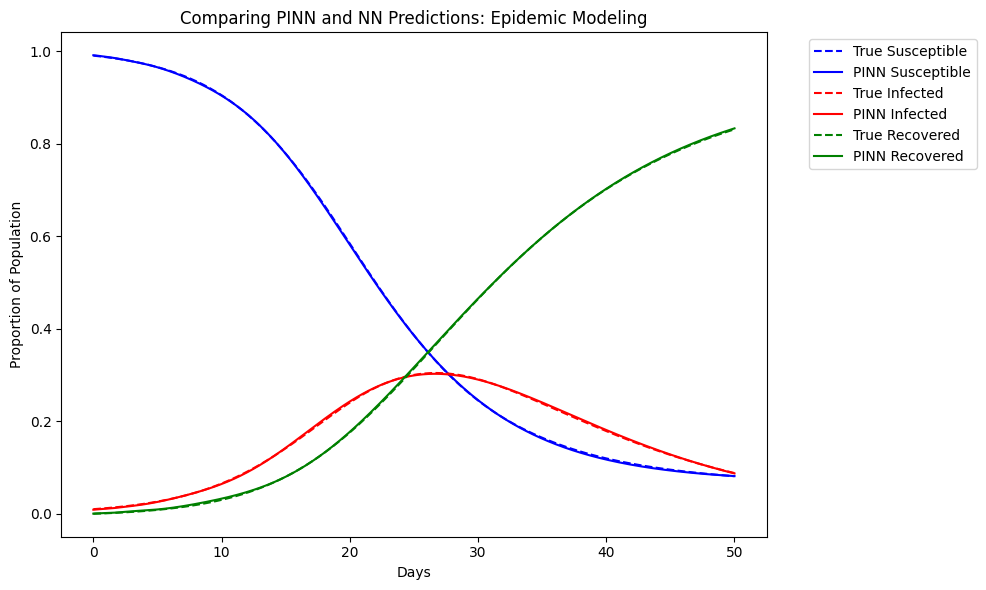

In [39]:
# Plot  Predictions vs Ground Truth
plt.figure(figsize=(10, 6))
labels = ['Susceptible', 'Infected', 'Recovered']
colors = ['blue', 'red', 'green']

for i in range(3):
    plt.plot(y_obs[:, 0], y_obs[:, i+1], label=f'True {labels[i]}', color=colors[i], linestyle='--')
    plt.plot(t_val.numpy(), pred_y_PINN[:, i].numpy(), label=f'PINN {labels[i]}', color=colors[i])

plt.title('Comparing PINN and NN Predictions: Epidemic Modeling')
plt.xlabel('Days')
plt.ylabel('Proportion of Population')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Discover equations using PySR

In [40]:
!pip install pysr

In [41]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

In [81]:
epi_pinn.eval()
with torch.no_grad():
        t_val = torch.linspace(t_span[0], t_span[1], 1000).reshape(-1, 1)
        pred_y_PINN, f = epi_pinn(t_val)
#print(t_val.numpy())
df = pd.DataFrame({
    't': t_val.numpy().flatten(),
    'x1': pred_y_PINN[:, 0].numpy(),
    'x2': pred_y_PINN[:, 1].numpy(),
    'x3': pred_y_PINN[:, 2].numpy(),
    'f': f.numpy().flatten(),
})

X = df.iloc[:, :4].to_numpy()
y = df.loc[:, 'f'].to_numpy()
print(df.iloc[:, :5].head)

<bound method NDFrame.head of              t        x1        x2        x3         f
0     0.000000  0.990813  0.000354  0.008842  0.002803
1     0.050050  0.990739  0.000512  0.008946  0.002444
2     0.100100  0.990628  0.000633  0.009042  0.002120
3     0.150150  0.990489  0.000725  0.009134  0.001829
4     0.200200  0.990330  0.000792  0.009222  0.001572
..         ...       ...       ...       ...       ...
995  49.799801  0.081799  0.831077  0.088609  0.007738
996  49.849850  0.081712  0.831524  0.088256  0.007696
997  49.899899  0.081627  0.831969  0.087905  0.007655
998  49.949951  0.081542  0.832412  0.087555  0.007614
999  50.000000  0.081457  0.832853  0.087206  0.007573

[1000 rows x 5 columns]>


In [82]:
default_pysr_params = dict(
    populations=30,
    model_selection="score",
    #loss="L1DistLoss()",
    elementwise_loss="loss(prediction, target) = (prediction - target)^2"
)

In [83]:
# Learn equations

# Learn equations
model = PySRRegressor(
    niterations=30,
    #binary_operators=["+", "*"],
    #unary_operators=["cos", "exp", "sin"],
    **default_pysr_params,
)

model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.390e+04
Progress: 278 / 900 total iterations (30.889%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.944e-05  0.000e+00  y = 0.015845
3           2.102e-07  3.027e+00  y = x₃ * 0.096084
5           1.202e-07  2.797e-01  y = (x₃ * 0.098804) - 0.00060231
11          1.113e-07  1.274e-02  y = -0.0005048 - ((x₃ * -0.099249) - ((0.39016 - x₀) * 7.1...
                                      286e-06))
13          1.111e-07  8.586e-04  y = (-0.079953 - (((x₃ + 0.7974) - -0.98678) * 0.0089678))...
                                       * (0.0049191 - x₃)
15          9.318e-08  8.812e-02  y = ((x₃ * (((x₃ * 56.422) + 1.1405) * 0.0033239)) / (x₃ +...
                                       0.033526)) * 0.53993
────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                        0.015844956   
	1   >>>>  3.026538e+00                                    x3 * 0.09608352   
	2         2.796856e-01                 -0.0006022908 - (x3 * -0.09880362)   
	3         3.411830e-06   -0.9809822 - ((x3 * -0.098803915) + -0.98037976)   
	4         1.852068e-01  (x3 * 0.100715384) - ((-1.2731732e-5 / x3) - -...   
	5         1.566813e-07  ((-0.0011022267 - (x3 * -0.100717045)) - (-1.2...   
	6         1.788130e-02  (-0.0014398814 - (x3 * ((x3 * 0.010860662) + -...   
	7         1.613578e-02  (-0.0011771093 - (x3 * -0.1005294)) - ((-1.352...   
	8         3.811814e-03  ((-0.00051914714 - (x3 * -0.0455834)) - ((-5.8...   
	9         7.804130e-02  (-0.10471411 - ((1.6172887 - x0) * (8.056427e-...   
	10        4.063430e-04  ((0.013159876 - x3) - (0.0001501861 / x3)) * (...   
	11        7.332632e-03  ((((x0 * (((x3 / -0.07546706) - -0.9637564) / ...   
	12        8.132439e-02  ((0.011857507 - x3) * (-0.102777176 - ((((-0.8...   
	
	            loss  complexity  
	0   8.944325e-05           1  
	1   2.102470e-07           3  
	2   1.201705e-07           5  
	3   1.201697e-07           7  
	4   8.297101e-08           9  
	5   8.297098e-08          11  
	6   8.005615e-08          13  
	7   7.751386e-08          15  
	8   7.692517e-08          17  
	9   6.580860e-08          19  
	10  6.575514e-08          21  
	11  6.479786e-08          23  
	12  5.507103e-08          25  
]

  - outputs/20260708_220726_XXo2sE/hall_of_fame.csv


In [77]:
model.sympy()
print("Correct: x2*", gamma)
print("Discovered:", model.sympy())

Correct: x2* 0.1
Discovered: x2*0.09608363
